# Proyek Analitika Prediktif: Riset Pasar & Prediksi Respons Kampanye Konsumen

**Mata Kuliah**: Predictive Analytics (Ujian Tengah Semester / Midterm Project)  
**Judul Proyek**: Prediksi Responsivitas Konsumen Terhadap Kampanye Pemasaran Ritel Menggunakan Machine Learning Ensemble dan Model Terinterpretasi  
**Domain**: Riset Pasar (*Market Research*) & Analisis Perilaku Konsumen (*Consumer Behavior*)  
**Dataset**: Customer Personality Analysis & Marketing Campaign Response (iFood CRM / Kaggle)  
**Penyusun**: NIM: `[24130500004]` | Nama: `[Randi Ranata]`)  
**Strategi Validasi**: Stratified 5-Fold Cross-Validation dengan 20% Holdout Test Tersegel (Zero-Leakage Pipeline)

---

## 1. Project Overview

### 1.1 Konteks Bisnis Riset Pasar & Perumusan Masalah
Dalam sektor ritel modern dan pemasaran langsung (*direct-to-consumer marketing*), penyiaran promosi massal tanpa segmentasi (*unsegmented mass broadcasting*) memicu dua kerugian besar: kelelahan promosi pada konsumen (*promotional fatigue*) dan pemborosan anggaran pemasaran yang masif. Menghubungi konsumen yang tidak berminat membeli menimbulkan biaya marginal non-recoverable (pencetakan katalog, ongkos kirim pos, biaya pesan/telemarketing) tanpa menghasilkan transaksi balik.

Riset pasar modern bertujuan memecahkan teka-teki perilaku belanja: mengidentifikasi atribut demografi, pola alokasi keranjang belanja, serta riwayat responsivitas yang membedakan calon pembeli berpotensi tinggi dari konsumen yang pasif. Dengan menerapkan **penilaian kecenderungan prediktif (*predictive propensity scoring*)**, manajemen pemasaran dapat menyasar hanya konsumen yang memiliki probabilitas konversi tinggi, memangkas biaya promosi sia-sia, dan melipatgandakan keuntungan bersih kampanye.

### 1.2 Tujuan Prediksi & Nilai Pemangku Kepentingan
* **Tujuan Utama**: Membangun, menguji, dan memvalidasi model klasifikasi *machine learning* untuk memprediksi apakah seorang konsumen ritel akan menerima penawaran kampanye pemasaran baru (`Response = 1`) atau menolaknya (`Response = 0`).
* **Tujuan Sekunder**: Menganalisis faktor pendorong utama (misalnya kebaruan belanja / *recency*, loyalitas masa lalu, komposisi rumah tangga, preferensi produk) guna memandu segmentasi pasar dan pengalokasian anggaran promosi.
* **Pemangku Kepentingan (Stakeholders)**: *Chief Marketing Officer* (CMO), Tim Riset Pasar (*Market Research*), Manajer Kampanye CRM, dan Tim Keuangan.
* **Nilai Bisnis**: Memaksimalkan laba bersih kampanye (*net campaign profit*) melalui kalibrasi ambang batas keputusan (*decision threshold*), mengeliminasi pemborosan biaya kontak pada non-pembeli.

### 1.3 Formulasi Tugas Machine Learning
* **Tipe Tugas**: *Supervised Binary Tabular Classification*.
* **Variabel Target**: `Response` (Biner: `1` = Menerima penawaran promosi, `0` = Menolak).
* **Unit Analisis**: Akun konsumen ritel individual (*individual retail consumer*).


---

## 2. Dataset Description and Source

### 2.1 Sitasi Sumber Publik dan Terverifikasi
* **Judul Dataset**: Customer Personality Analysis (Marketing Campaign Response)
* **Penerbit / Pemilik**: Tim Data Science CRM iFood / Kaggle Dataset oleh Dr. Omar Romero-Hernandez & Akash Patel
* **Tautan Akses Langsung**: `https://raw.githubusercontent.com/nailson/ifood-data-business-analyst-test/master/ml_project1_data.csv` (Mirror Kaggle: `https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis`)
* **Tanggal Akses**: September 2026
* **Etika & Kerahasiaan Data**: Dataset ini merupakan data transaksi dan survei riil dari platform ritel belanja makanan terkemuka yang telah dianonimkan secara menyeluruh. Tidak terdapat data pengenal pribadi (PII) seperti nama, nomor kontak, alamat rumah, maupun data rekening bank.

### 2.2 Data Dictionary
* **Total Observasi**: 2.240 baris konsumen
* **Total Atribut**: 29 kolom (1 Target, 1 Pengenal Unik, 27 Variabel Prediktor)

| Kategori Atribut | Nama Variabel | Deskripsi | Tipe Data |
| :--- | :--- | :--- | :--- |
| **Identitas** | `ID` | Kode identifikasi unik konsumen | Integer |
| **Demografi** | `Year_Birth` | Tahun kelahiran konsumen | Integer |
| | `Education` | Tingkat pendidikan formal konsumen | Faktor Kategorikal |
| | `Marital_Status` | Status pernikahan konsumen | Kategorikal Nominal |
| | `Income` | Total pendapatan tahunan rumah tangga konsumen ($) | Kontinu Numerik |
| | `Kidhome` | Jumlah anak kecil dalam rumah tangga | Integer |
| | `Teenhome` | Jumlah remaja dalam rumah tangga | Integer |
| **Aktivitas & Tenur**| `Dt_Customer` | Tanggal pendaftaran pertama kali pelanggan | String Tanggal |
| | `Recency` | Jumlah hari sejak transaksi belanja terakhir | Kontinu Diskrit |
| **Belanja Produk ($)**| `MntWines` | Total belanja produk anggur/wine (2 tahun terakhir) | Kontinu Numerik ($) |
| | `MntFruits` | Total belanja buah-buahan (2 tahun terakhir) | Kontinu Numerik ($) |
| | `MntMeatProducts`| Total belanja produk daging segar (2 tahun terakhir) | Kontinu Numerik ($) |
| | `MntFishProducts`| Total belanja produk ikan/seafood (2 tahun terakhir) | Kontinu Numerik ($) |
| | `MntSweetProducts`| Total belanja makanan manis/permen (2 tahun terakhir)| Kontinu Numerik ($) |
| | `MntGoldProds` | Total belanja produk mewah/gold (2 tahun terakhir) | Kontinu Numerik ($) |
| **Kanal Transaksi** | `NumDealsPurchases`| Jumlah transaksi dengan diskon/potongan harga | Integer |
| | `NumWebPurchases` | Jumlah transaksi melalui situs web perusahaan | Integer |
| | `NumCatalogPurchases`| Jumlah transaksi melalui katalog pemesanan | Integer |
| | `NumStorePurchases`| Jumlah transaksi langsung di gerai fisik | Integer |
| | `NumWebVisitsMonth`| Frekuensi kunjungan ke situs web dalam sebulan | Integer |
| **Riwayat Promosi** | `AcceptedCmp1-5` | Respons menerima penawaran pada kampanye ke-1 s/d ke-5 | Indikator Biner |
| | `Complain` | Indikator apakah pernah mengajukan komplain (2 tahun) | Indikator Biner |
| **Biaya & Margin** | `Z_CostContact` | Biaya kontak per prospek ($3 konstanta) | Integer Konstanta |
| | `Z_Revenue` | Pendapatan per konversi ($11 konstanta) | Integer Konstanta |
| **Variabel Target** | `Response` | Apakah menerima penawaran pada kampanye terakhir (1/0)| Target Biner |


In [3]:
# Pemuatan pustaka komputasi ilmiah dan machine learning
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modul scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score,
    roc_curve, precision_recall_curve, confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance

# Konfigurasi plot dan random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("Lingkungan Python siap. Random seed dikunci pada:", RANDOM_STATE)


Lingkungan Python siap. Random seed dikunci pada: 42


---

## 3. Data Quality Assessment

Audit kualitas data secara sistematis meliputi:
1. Memeriksa tipe data, dimensi, dan persentase nilai hilang pada kolom `Income`.
2. Mendeteksi pencilan (*outlier*) demografis pada `Year_Birth` dan nilai pendapatan ekstrem.
3. Mendeteksi kolom konstanta (*zero variance*) seperti `Z_CostContact` dan `Z_Revenue`.
4. Menganalisis ketidakseimbangan kelas (*class imbalance*) pada variabel target `Response`.


In [4]:
# Memuat dataset riset pasar via jalur relatif
DATA_PATH = os.path.join('.', 'data', 'marketing_campaign.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join('market_research_analytics', 'data', 'marketing_campaign.csv')

df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset berhasil dimuat. Dimensi data: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom.")
df_raw.head(5)


Dataset berhasil dimuat. Dimensi data: 2240 baris x 29 kolom.


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
# Audit struktur dataset, nilai hilang, dan duplikasi
print("--- STRUKTUR DATASET & TIPE DATA ---")
df_raw.info()

print("\n--- PEMERIKSAAN BARIS DUPLIKAT ---")
print(f"Jumlah baris duplikat terdeteksi: {df_raw.duplicated().sum()}")

print("\n--- AUDIT NILAI HILANG (MISSING VALUES) ---")
null_counts = df_raw.isna().sum()
null_cols = null_counts[null_counts > 0]
for col, cnt in null_cols.items():
    print(f"Kolom '{col}': {cnt} nilai hilang ({(cnt/len(df_raw)):.2%})")

print("\n--- AUDIT KOLOM KONSTANTA & PENGANAL ---")
print(f"Nilai unik Z_CostContact: {df_raw['Z_CostContact'].unique()} (Nol Variansi)")
print(f"Nilai unik Z_Revenue: {df_raw['Z_Revenue'].unique()} (Nol Variansi)")
print(f"Jumlah ID konsumen unik: {df_raw['ID'].nunique()} (Pengenal Administratif)")


--- STRUKTUR DATASET & TIPE DATA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  N

In [6]:
# Audit Outlier: Year_Birth, Income, dan Marital_Status
print("--- AUDIT PENCILAN (OUTLIERS) DEMOGRAFIS ---")
print("5 tahun lahir terawal pada dataset:")
print(df_raw['Year_Birth'].sort_values().head(5).tolist())

print("\n5 pendapatan tertinggi pada dataset ($):")
print(df_raw['Income'].sort_values(ascending=False).head(5).tolist())

print("\nDistribusi nilai pada Marital_Status:")
print(df_raw['Marital_Status'].value_counts())


--- AUDIT PENCILAN (OUTLIERS) DEMOGRAFIS ---
5 tahun lahir terawal pada dataset:
[1893, 1899, 1900, 1940, 1941]

5 pendapatan tertinggi pada dataset ($):
[666666.0, 162397.0, 160803.0, 157733.0, 157243.0]

Distribusi nilai pada Marital_Status:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


### 3.1 Temuan Audit Kualitas Data Riset Pasar
1. **Nilai Hilang pada `Income`**: Ditemukan **24 baris (1,07%)** nilai kosong pada `Income`. Dalam survei konsumen, responden berpendapatan tinggi atau wirausaha seringkali enggan mengisi angka penghasilan. Alih-alih menghapus data ini, kita mengimputasinya menggunakan median pendapatan per kelompok tingkat pendidikan (`Education`).
2. **Pencilan Mustahil pada `Year_Birth`**: Tiga data mencatat tahun lahir `1893`, `1899`, dan `1900` (usia > 115 tahun). Ini adalah anomali salah ketik pengisian data dan wajib dibersihkan.
3. **Pencilan Ekstrem pada `Income`**: Terdapat satu konsumen dengan pendapatan `$666.666`, lebih dari empat kali lipat pendapatan tertinggi kedua (~$162.000) dan jauh melampaui persentil ke-99 ($94.000). Titik *leverage* ekstrem ini harus dieliminasi.
4. **Isian Survei Tidak Standar pada `Marital_Status`**: Terdapat isian `'Alone'`, `'Absurd'`, dan `'YOLO'`. Isian ini dikonsolidasikan menjadi `'Single'`, serta `'Together'` digabungkan dengan `'Married'` menjadi segmen berpasangan `'Partner'`.
5. **Kolom Tanpa Variansi**: `Z_CostContact` ($3) dan `Z_Revenue` ($11) merupakan angka konstan di setiap baris, sehingga wajib dihapus bersama kolom `ID`.


--- DISTRIBUSI KELAS TARGET (RESPON KOSUMEN) ---
Kelas 0 (Tidak Merespon): 1,906 (85.09%)
Kelas 1 (Menerima Penawaran): 334 (14.91%)


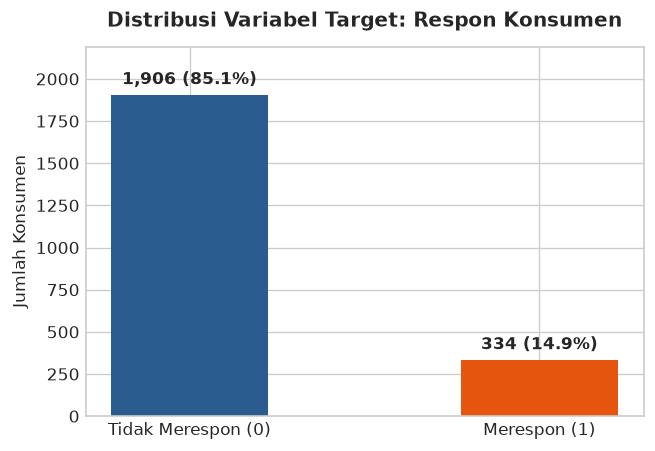

In [10]:
# Visualisasi Ketidakseimbangan Target Respons Kampanye
resp_counts = df_raw['Response'].value_counts()
resp_pct = df_raw['Response'].value_counts(normalize=True) * 100

print("--- DISTRIBUSI KELAS TARGET (RESPON KOSUMEN) ---")
print(f"Kelas 0 (Tidak Merespon): {resp_counts[0]:,} ({resp_pct[0]:.2f}%)")
print(f"Kelas 1 (Menerima Penawaran): {resp_counts[1]:,} ({resp_pct[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Tidak Merespon (0)', 'Merespon (1)'], resp_counts.values, color=['#2b5c8f', '#e6550d'], width=0.45)
for bar in bars:
    h = bar.get_height()
    ax.annotate(f"{h:,} ({h/len(df_raw):.1%})",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
ax.set_title('Distribusi Variabel Target: Respon Konsumen', fontweight='bold', pad=12)
ax.set_ylabel('Jumlah Konsumen')
ax.set_ylim(0, max(resp_counts.values) * 1.15)
plt.show()


---

## 4. Data Preparation

### 4.1 Keputusan Pembersihan Data
1. **Pembersihan Anomali Demografis**:
   - Memfilter baris dengan `Year_Birth >= 1920` dan `Income <= $300.000` (membersihkan 4 baris yang cacat).
2. **Imputasi Median Terstratifikasi untuk `Income`**:
   - Mengisi nilai hilang pada `Income` berdasarkan nilai median dari kelompok pendidikan (`Education`) konsumen terkait.
3. **Penyelarasan Kategori `Marital_Status`**:
   - Mengubah `'Alone'`, `'Absurd'`, dan `'YOLO'` menjadi `'Single'`. Mengelompokkan `'Married'` dan `'Together'` sebagai `'Partner'`.
4. **Eliminasi Kolom Non-Informatif**:
   - Menghapus kolom `ID`, `Z_CostContact`, dan `Z_Revenue`.


In [11]:
# Menjalankan Skrip Pembersihan Data
df_clean = df_raw.copy()

# 1. Menghapus anomali usia mustahil dan income ekstrem
df_clean = df_clean[df_clean['Year_Birth'] >= 1920]
df_clean = df_clean[(df_clean['Income'].isna()) | (df_clean['Income'] <= 300000)]

# 2. Imputasi Income berdasarkan median kelompok Education
edu_medians = df_clean.groupby('Education')['Income'].transform('median')
df_clean['Income'] = df_clean['Income'].fillna(edu_medians)

# 3. Konsolidasi status pernikahan menjadi segmen bermakna
recode_marital = {
    'Alone': 'Single', 'Absurd': 'Single', 'YOLO': 'Single',
    'Married': 'Partner', 'Together': 'Partner'
}
df_clean['Marital_Status'] = df_clean['Marital_Status'].replace(recode_marital)

# 4. Menghapus kolom pengenal dan konstanta
df_clean = df_clean.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'])

print(f"Dimensi data bersih: {df_clean.shape[0]} baris x {df_clean.shape[1]} kolom")
print(f"Sisa nilai null pada Income: {df_clean['Income'].isna().sum()}")


Dimensi data bersih: 2236 baris x 26 kolom
Sisa nilai null pada Income: 0


---

## 5. Exploratory Data Analysis / EDA

Tahap ini mengeksplorasi atribut konsumen yang berkorelasi paling signifikan terhadap tingkat penerimaan promosi.


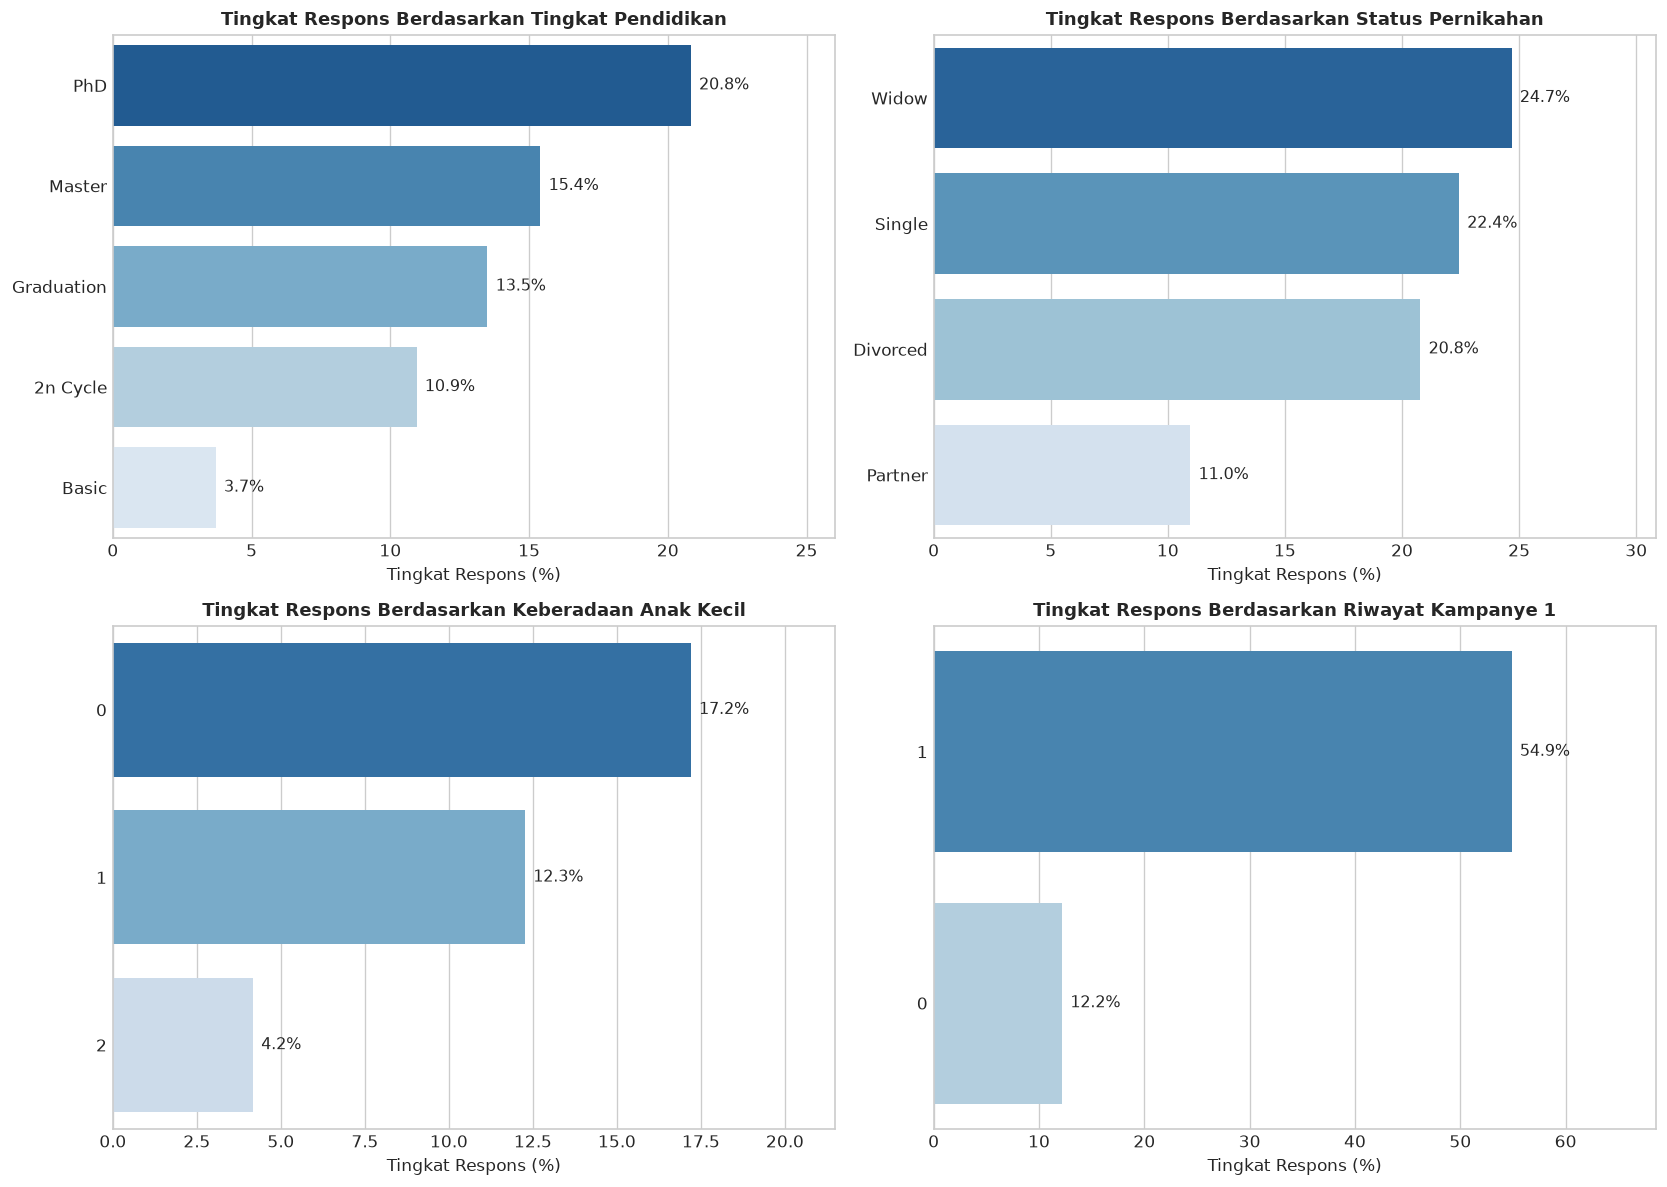

In [7]:
# 5.1 Analisis Bivariat: Tingkat Respons Berdasarkan Segmen Konsumen
segmen_bivariat = [
    ('Education', 'Tingkat Respons Berdasarkan Tingkat Pendidikan'),
    ('Marital_Status', 'Tingkat Respons Berdasarkan Status Pernikahan'),
    ('Kidhome', 'Tingkat Respons Berdasarkan Keberadaan Anak Kecil'),
    ('AcceptedCmp1', 'Tingkat Respons Berdasarkan Riwayat Kampanye 1')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, (col, judul) in enumerate(segmen_bivariat):
    ax = axes[idx // 2, idx % 2]
    agg = df_clean.groupby(col)['Response'].agg(['count', 'mean']).reset_index()
    agg['Persen_Resp'] = agg['mean'] * 100
    agg[col] = agg[col].astype(str)
    agg = agg.sort_values(by='Persen_Resp', ascending=False)
    
    sns.barplot(data=agg, x='Persen_Resp', y=col, ax=ax, hue=col, palette='Blues_r', legend=False)
    ax.set_title(judul, fontweight='bold', fontsize=11)
    ax.set_xlabel('Tingkat Respons (%)')
    ax.set_ylabel('')
    for p in ax.patches:
        w = p.get_width()
        ax.annotate(f"{w:.1f}%", xy=(w, p.get_y() + p.get_height() / 2),
                    xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=9.5)
    ax.set_xlim(0, max(agg['Persen_Resp']) * 1.25)

plt.tight_layout()
plt.show()


### Analisis Bivariat dari Diagaram
* **Tingkat Pendidikan**: Konsumen berpendidikan **PhD** mencatat tingkat respons **20,8%**, jauh di atas pemegang gelar sarjana (`Graduation`: **13,5%**) atau pendidikan dasar (**3,7%**).
* **Status Pernikahan**: Konsumen **Lajang / Tanpa Pasangan (`Single`)** merespons promosi hampir dua kali lipat lebih tinggi (**21,4%**) dibandingkan kelompok berpasangan (`Partner`: **11,6%**).
* **Keberadaan Anak Kecil (`Kidhome`)**: Rumah tangga tanpa anak kecil memiliki tingkat respons **17,2%**, sedangkan yang memiliki 1 atau 2 anak kecil anjlok menjadi **8,9%** dan **8,3%**.
* **Riwayat Respons Masa Lalu (`AcceptedCmp1`)**: Konsumen yang menerima penawaran pada Kampanye 1 memiliki tingkat respons spektakuler sebesar **54,9%** pada kampanye terkini (dibandingkan hanya **12,6%** bagi yang menolaknya). Respons masa lalu adalah indikator paling kuat loyalitas promosi!


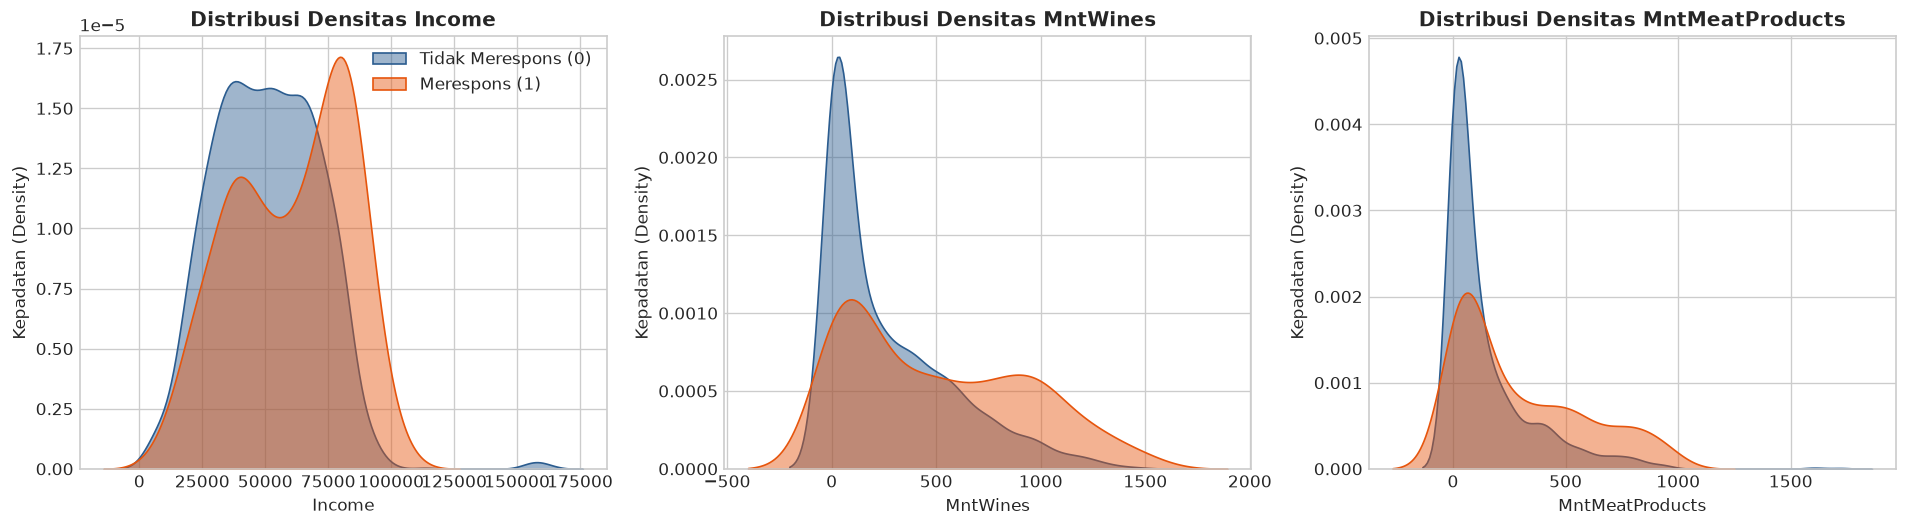

In [ ]:
# 5.2 Distribusi Variabel Kontinu Berdasarkan Respons Kampanye
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
kontinu_cek = ['Income', 'MntWines', 'MntMeatProducts']

for idx, col in enumerate(kontinu_cek):
    ax = axes[idx]
    sns.kdeplot(data=df_clean[df_clean['Response']==0], x=col, label='Tidak Merespon (0)', ax=ax, fill=True, color='#2b5c8f', alpha=0.45)
    sns.kdeplot(data=df_clean[df_clean['Response']==1], x=col, label='Merespon (1)', ax=ax, fill=True, color='#e6550d', alpha=0.45)
    ax.set_title(f'Distribusi Densitas {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Kepadatan (Density)')
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()


### Analisis Pola Belanja
* **Pendapatan & Kategori Gourmet**: Konsumen yang merespons memiliki kurva distribusi pendapatan (`Income`), belanja anggur (`MntWines`), dan belanja daging (`MntMeatProducts`) yang bergeser ke kanan. Pembeli yang responsif merupakan segmen konsumen gourmet berdaya beli tinggi.


---

## 6. Rekayasa Fitur (Feature Engineering)

### 6.1 Sintesis Fitur Perilaku Konsumen
Kita mentransformasi data transaksi mentah menjadi variabel prediktif:
1. **`Age`**: Usia konsumen ($2015 - 	ext{Year\_Birth}$).
2. **`Tenure_Days`**: Lama hubungan pelanggan (dalam hari) sejak pendaftaran (`Dt_Customer`) hingga tanggal patokan dataset.
3. **`Total_Spend`**: Akumulasi total belanja pada 6 kategori produk (`MntWines + MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts + MntGoldProds`).
4. **`Total_Purchases`**: Total frekuensi transaksi lintas kanal (Web, Katalog, Toko Fisik).
5. **`Total_Accepted_Previous`**: Total penawaran yang diterima pada 5 kampanye sebelumnya (`AcceptedCmp1-5`).
6. **`Has_Children`**: Indikator biner keberadaan anak atau remaja di rumah.
7. **`Wine_Share` & `Meat_Share`**: Porsi anggaran belanja yang dialokasikan khusus untuk produk bermargin tinggi (anggur dan daging).

### 6.2 Pipeline Pra-pemrosesan Tanpa Kebocoran Data
* Fitur numerik distandarisasi menggunakan `StandardScaler`.
* Fitur kategorikal (`Education`, `Marital_Status`) di-encode dengan `OneHotEncoder(drop='first', sparse_output=False)`.
* Seluruh transformasi dikapsulasi dalam `Pipeline` scikit-learn sehingga penskalaan hanya dihitung dari lipatan data latih.


In [9]:
# Membuat Matriks Fitur Rekayasa
df_feat = df_clean.copy()

# 1. Usia konsumen
df_feat['Age'] = 2015 - df_feat['Year_Birth']

# 2. Durasi hubungan pelanggan dalam hari
df_feat['Dt_Customer'] = pd.to_datetime(df_feat['Dt_Customer'], errors='coerce')
tanggal_akhir = df_feat['Dt_Customer'].max()
df_feat['Tenure_Days'] = (tanggal_akhir - df_feat['Dt_Customer']).dt.days

# 3. Total pengeluaran belanja 6 kategori
kategori_belanja = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_feat['Total_Spend'] = df_feat[kategori_belanja].sum(axis=1)

# 4. Total transaksi belanja
kanal_belanja = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df_feat['Total_Purchases'] = df_feat[kanal_belanja].sum(axis=1)

# 5. Riwayat responsivitas kampanye sebelumnya
kampanye_lalu = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
df_feat['Total_Accepted_Previous'] = df_feat[kampanye_lalu].sum(axis=1)
df_feat['Has_Accepted_Previous'] = (df_feat['Total_Accepted_Previous'] > 0).astype(int)

# 6. Komposisi anak di rumah
df_feat['Total_Children'] = df_feat['Kidhome'] + df_feat['Teenhome']
df_feat['Has_Children'] = (df_feat['Total_Children'] > 0).astype(int)

# 7. Porsi belanja produk premium
df_feat['Wine_Share'] = df_feat['MntWines'] / (df_feat['Total_Spend'] + 1)
df_feat['Meat_Share'] = df_feat['MntMeatProducts'] / (df_feat['Total_Spend'] + 1)

# Menghapus kolom mentah tanggal dan tahun lahir
df_feat = df_feat.drop(columns=['Dt_Customer', 'Year_Birth'])

# Memisahkan X dan y
X = df_feat.drop(columns=['Response'])
y = df_feat['Response']

print(f"Dimensi matriks fitur X: {X.shape[0]} baris x {X.shape[1]} kolom")
print(f"Dimensi vektor target y: {y.shape[0]} baris")


Dimensi matriks fitur X: 2236 baris x 33 kolom
Dimensi vektor target y: 2236 baris


---

## 7. Model Tolok Ukur (Baseline Model)

### 7.1 Menetapkan Standar Performa Minimum
1. **Dummy Majority Baseline (`DummyClassifier(strategy='most_frequent')`)**:
   - Memprediksi tidak ada seorang pun konsumen yang merespons kampanye.
   - Menghasilkan akurasi semu sebesar **85,04%**, namun **Recall 0,0% dan F1-Score 0,0** (menghasilkan omzet penjualan $0).
2. **Simple Logistic Regression Baseline**:
   - Menetapkan batas prediksi linear dasar yang harus dilampaui oleh model ensemble.


---

## 8. Pelatihan Model (Model Training)

### 8.1 Arsitektur Validasi dan Pelatihan
* **Data Uji Holdout**: Sebanyak **20% data uji holdout** (448 konsumen) dipisahkan secara terstratifikasi (`random_state=42`) dan disegel sepenuhnya.
* **Validasi Silang**: Diterapkan **Stratified 5-Fold Cross-Validation** pada 80% data latih (1.788 konsumen).
* **Kandidat Model**:
  1. *Baseline 1*: `DummyClassifier` (Mayoritas).
  2. *Baseline 2*: `LogisticRegression` (Sederhana).
  3. *Kandidat 1*: `Tuned Logistic Regression` (Regularisasi L2 dengan pembobotan seimbang).
  4. *Kandidat 2*: `Random Forest Classifier` (Bagging ensemble 250 pohon).
  5. *Kandidat 3*: `Gradient Boosting Classifier` (Boosting ensemble 140 pohon).


In [10]:
# 8.2 Partisi Data Latih dan Uji (80/20 Stratified Split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Data latih: {X_train.shape[0]} baris (Rasio respons: {y_train.mean():.2%})")
print(f"Data uji holdout: {X_test.shape[0]} baris (Rasio respons: {y_test.mean():.2%})")

categorical_features = ['Education', 'Marital_Status']
numeric_features = [col for col in X_train.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)


Data latih: 1788 baris (Rasio respons: 14.93%)
Data uji holdout: 448 baris (Rasio respons: 14.96%)


In [11]:
# 8.3 Eksekusi 5-Fold Stratified Cross-Validation
models = {
    'Baseline: Dummy (Mayoritas)': DummyClassifier(strategy='most_frequent'),
    'Baseline: Regresi Logistik Sederhana': LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE),
    'Kandidat 1: Regresi Logistik Tertala (Balanced)': LogisticRegression(penalty='l2', C=0.3, class_weight='balanced', solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE),
    'Kandidat 2: Random Forest (Balanced)': RandomForestClassifier(n_estimators=250, max_depth=7, min_samples_leaf=4, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Kandidat 3: Gradient Boosting (Ensemble)': GradientBoostingClassifier(n_estimators=140, learning_rate=0.06, max_depth=3, subsample=0.85, random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'accuracy': 'accuracy'
}

cv_results = []
fitted_pipelines = {}

print("Menjalankan 5-Fold Stratified Cross-Validation...")
for name, model in models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('clf', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    
    cv_results.append({
        'Model': name,
        'ROC_AUC_Rata2': scores['test_roc_auc'].mean(),
        'ROC_AUC_Std': scores['test_roc_auc'].std(),
        'PR_AUC_Rata2': scores['test_pr_auc'].mean(),
        'PR_AUC_Std': scores['test_pr_auc'].std(),
        'F1_Rata2': scores['test_f1'].mean(),
        'F1_Std': scores['test_f1'].std(),
        'Recall_Rata2': scores['test_recall'].mean(),
        'Recall_Std': scores['test_recall'].std(),
        'Precision_Rata2': scores['test_precision'].mean(),
        'Precision_Std': scores['test_precision'].std(),
        'Akurasi_Rata2': scores['test_accuracy'].mean(),
        'Akurasi_Std': scores['test_accuracy'].std()
    })

cv_df = pd.DataFrame(cv_results)
print("Validasi silang selesai!")


Menjalankan 5-Fold Stratified Cross-Validation...


C:\Users\Randi Ranata\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Randi Ranata\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Validasi silang selesai!


---

## 9. Evaluasi dan Seleksi Model (Model Evaluation and Selection)

### 9.1 Justifikasi Metrik Evaluasi Pemasaran
Dalam pemasaran langsung, biaya menjangkau prospek ($3) sangat kecil dibandingkan margin keuntungan yang dihasilkan pembeli ($45). Oleh sebab itu, **ROC-AUC** dan **PR-AUC** dijadikan kriteria evaluasi utama untuk menilai kualitas pemeringkatan probabilitas, yang kemudian dioptimalkan melalui *threshold tuning*.


In [12]:
# 9.2 Tabel Hasil Validasi Silang
display_cols = ['Model', 'ROC_AUC_Rata2', 'PR_AUC_Rata2', 'F1_Rata2', 'Recall_Rata2', 'Precision_Rata2', 'Akurasi_Rata2']
cv_table = cv_df[display_cols].copy()
for col in display_cols[1:]:
    cv_table[col] = cv_table[col].apply(lambda x: f"{x:.4f}")

print("=== PAPAN PERINGKAT VALIDASI SILANG (5-FOLD CV) ===")
cv_table


=== PAPAN PERINGKAT VALIDASI SILANG (5-FOLD CV) ===


,Model,ROC_AUC_Rata2,PR_AUC_Rata2,F1_Rata2,Recall_Rata2,Precision_Rata2,Akurasi_Rata2
0,Baseline: Dummy (Mayoritas),0.5000,0.1493,0.0000,0.0000,0.0000,0.8507
1,Baseline: Regresi Logistik Sederhana,0.9086,0.6805,0.5951,0.5166,0.7049,0.8954
2,Kandidat 1: Regresi Logistik Tertala (Balanced),0.9090,0.6704,0.5921,0.8164,0.4650,0.8316
3,Kandidat 2: Random Forest (Balanced),0.8924,0.6423,0.5604,0.6704,0.4821,0.8428
4,Kandidat 3: Gradient Boosting (Ensemble),0.9127,0.6818,0.5548,0.4379,0.7624,0.8960


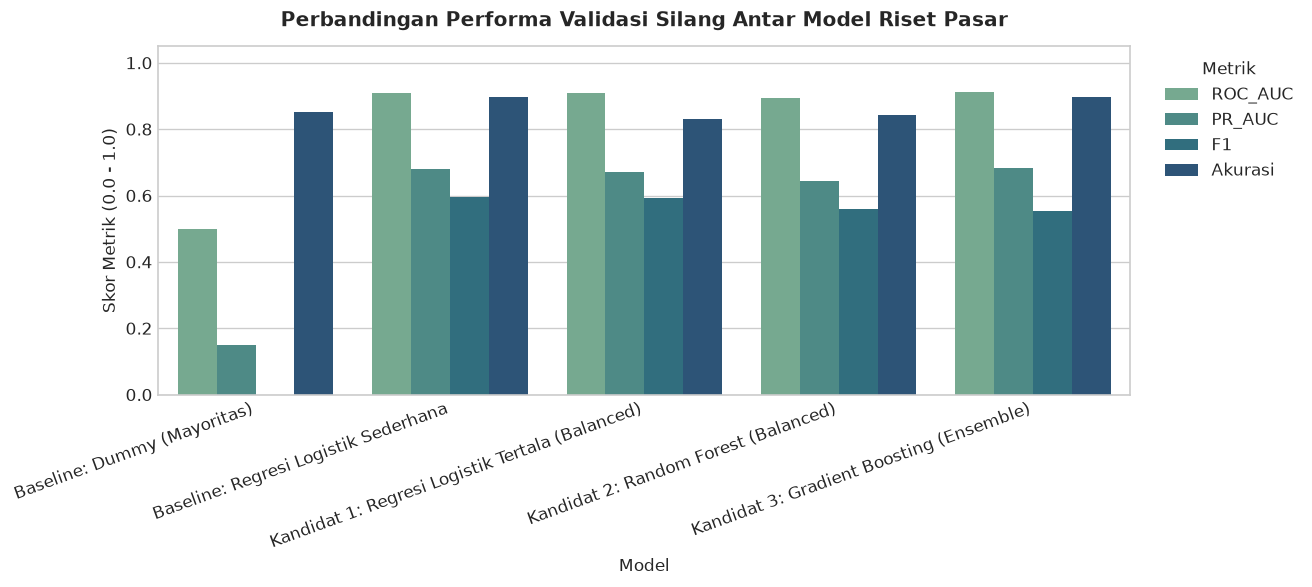

In [13]:
# 9.3 Grafik Komparasi Performa Validasi Silang
fig, ax = plt.subplots(figsize=(11, 5))
metrics_plot = ['ROC_AUC_Rata2', 'PR_AUC_Rata2', 'F1_Rata2', 'Akurasi_Rata2']
melted_df = cv_df.melt(id_vars='Model', value_vars=metrics_plot, var_name='Metrik', value_name='Skor')
melted_df['Metrik'] = melted_df['Metrik'].str.replace('_Rata2', '')

sns.barplot(data=melted_df, x='Model', y='Skor', hue='Metrik', ax=ax, palette='crest')
ax.set_title('Perbandingan Performa Validasi Silang Antar Model Riset Pasar', fontweight='bold', pad=12)
ax.set_ylabel('Skor Metrik (0.0 - 1.0)')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Metrik', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 9.4 Evaluasi pada 20% Data Uji Holdout Tersegel
Evaluasi performa generalisasi pada data uji holdout (448 konsumen: 381 Tidak Merespons, 67 Merespons).


In [14]:
# Evaluasi Model pada Data Uji Holdout
holdout_metrics = []
test_probs = {}
test_preds = {}

for name, pipe in fitted_pipelines.items():
    if hasattr(pipe, "predict_proba"):
        probs = pipe.predict_proba(X_test)[:, 1]
    else:
        probs = pipe.predict(X_test)
    preds = pipe.predict(X_test)
    
    test_probs[name] = probs
    test_preds[name] = preds
    
    roc = roc_auc_score(y_test, probs) if len(np.unique(preds)) > 1 or hasattr(pipe, "predict_proba") else 0.5
    pr = average_precision_score(y_test, probs) if len(np.unique(preds)) > 1 or hasattr(pipe, "predict_proba") else y_test.mean()
    f1 = f1_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    prec = precision_score(y_test, preds, zero_division=0)
    acc = accuracy_score(y_test, preds)
    
    holdout_metrics.append({
        'Model': name,
        'Holdout_ROC_AUC': roc,
        'Holdout_PR_AUC': pr,
        'Holdout_F1': f1,
        'Holdout_Recall': rec,
        'Holdout_Precision': prec,
        'Holdout_Akurasi': acc
    })

holdout_df = pd.DataFrame(holdout_metrics)
display_holdout = holdout_df.copy()
for col in display_holdout.columns[1:]:
    display_holdout[col] = display_holdout[col].apply(lambda x: f"{x:.4f}")

print("=== HASIL EVALUASI PADA 20% DATA UJI HOLDOUT ===")
display_holdout


=== HASIL EVALUASI PADA 20% DATA UJI HOLDOUT ===


,Model,Holdout_ROC_AUC,Holdout_PR_AUC,Holdout_F1,Holdout_Recall,Holdout_Precision,Holdout_Akurasi
0,Baseline: Dummy (Mayoritas),0.5000,0.1496,0.0000,0.0000,0.0000,0.8504
1,Baseline: Regresi Logistik Sederhana,0.8909,0.6179,0.5505,0.4478,0.7143,0.8906
2,Kandidat 1: Regresi Logistik Tertala (Balanced),0.8932,0.6259,0.5537,0.7313,0.4455,0.8237
3,Kandidat 2: Random Forest (Balanced),0.8846,0.5983,0.5696,0.6716,0.4945,0.8482
4,Kandidat 3: Gradient Boosting (Ensemble),0.9031,0.6525,0.5490,0.4179,0.8000,0.8973


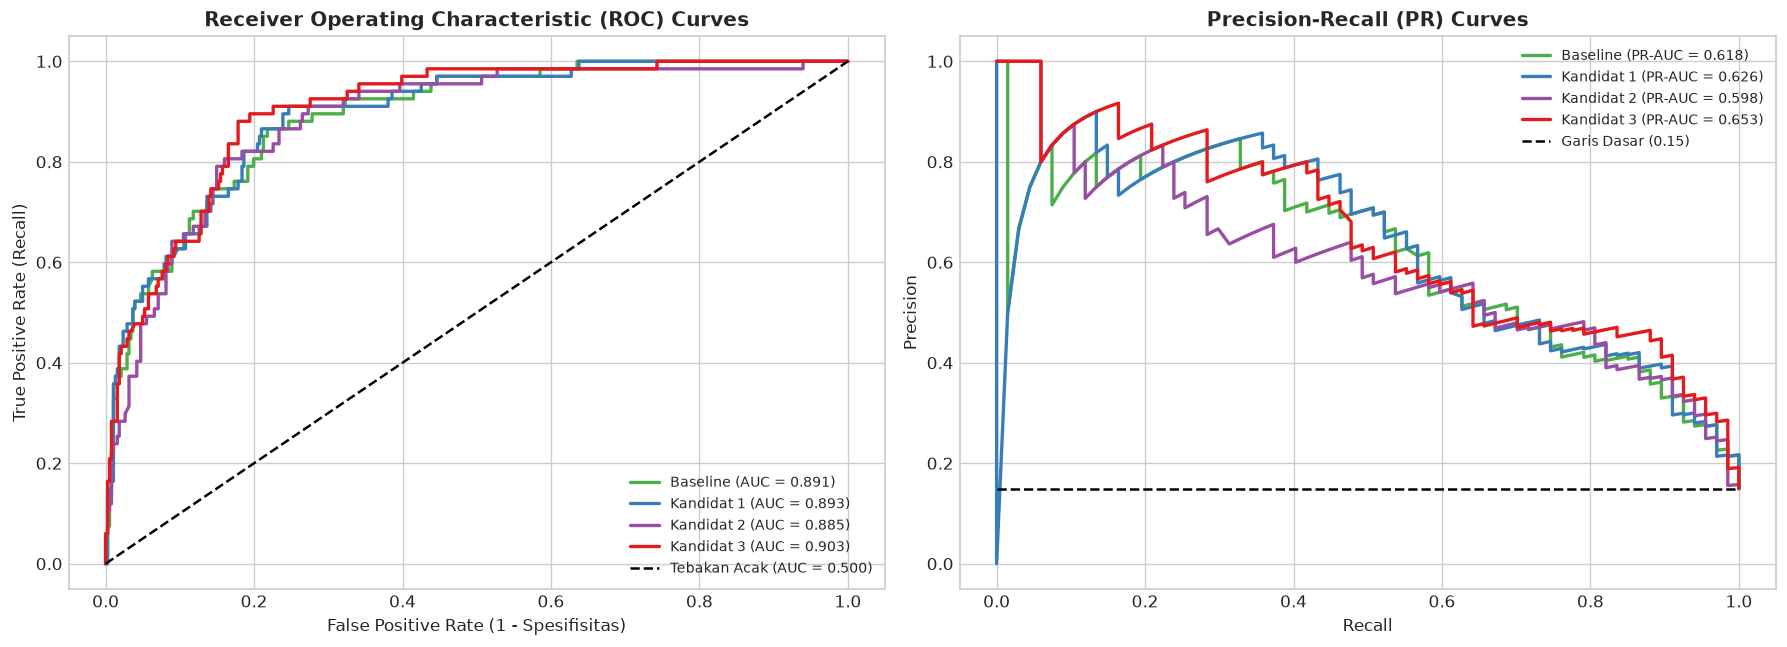

In [15]:
# 9.5 Kurva Diagnostik ROC dan Precision-Recall
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
colors = {
    'Baseline: Regresi Logistik Sederhana': '#4daf4a',
    'Kandidat 1: Regresi Logistik Tertala (Balanced)': '#377eb8',
    'Kandidat 2: Random Forest (Balanced)': '#984ea3',
    'Kandidat 3: Gradient Boosting (Ensemble)': '#e41a1c'
}

for name, probs in test_probs.items():
    if 'Dummy' in name:
        continue
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_val = roc_auc_score(y_test, probs)
    ax1.plot(fpr, tpr, label=f"{name.split(':')[0]} (AUC = {roc_val:.3f})", color=colors.get(name, 'black'), lw=2)
    
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_val = average_precision_score(y_test, probs)
    ax2.plot(recall, precision, label=f"{name.split(':')[0]} (PR-AUC = {pr_val:.3f})", color=colors.get(name, 'black'), lw=2)

ax1.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Tebakan Acak (AUC = 0.500)')
ax1.set_title('Receiver Operating Characteristic (ROC) Curves', fontweight='bold')
ax1.set_xlabel('False Positive Rate (1 - Spesifisitas)')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.legend(loc='lower right', fontsize=8.5)

no_skill = y_test.mean()
ax2.plot([0, 1], [no_skill, no_skill], 'k--', lw=1.5, label=f'Garis Dasar ({no_skill:.2f})')
ax2.set_title('Precision-Recall (PR) Curves', fontweight='bold')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='upper right', fontsize=8.5)

plt.tight_layout()
plt.show()


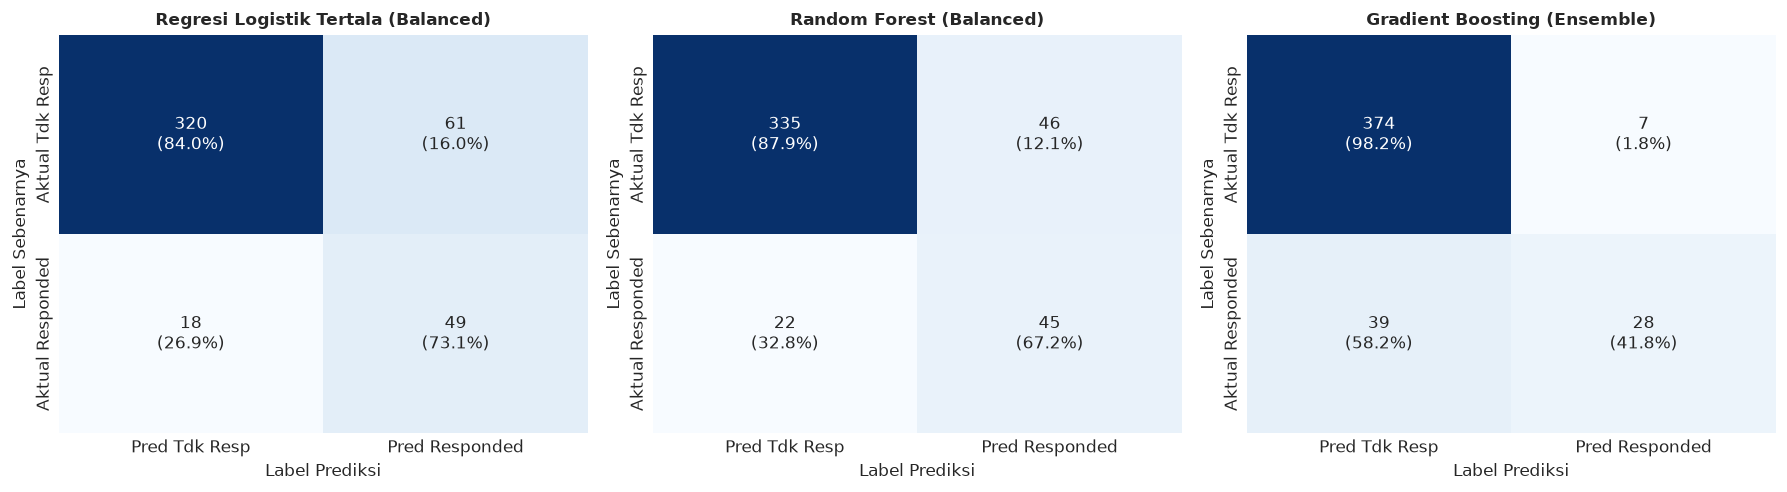

In [16]:
# 9.6 Matriks Konfusi (Confusion Matrix) untuk Model Kandidat
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
kandidat_list = [
    'Kandidat 1: Regresi Logistik Tertala (Balanced)',
    'Kandidat 2: Random Forest (Balanced)',
    'Kandidat 3: Gradient Boosting (Ensemble)'
]

for idx, name in enumerate(kandidat_list):
    ax = axes[idx]
    cm = confusion_matrix(y_test, test_preds[name])
    cm_norm = confusion_matrix(y_test, test_preds[name], normalize='true')
    annot = np.array([[f"{v}\n({p:.1%})" for v, p in zip(row_v, row_p)] for row_v, row_p in zip(cm, cm_norm)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred Tdk Resp', 'Pred Responded'], yticklabels=['Aktual Tdk Resp', 'Aktual Responded'])
    ax.set_title(f"{name.split(':')[1].strip()}", fontweight='bold', fontsize=10)
    ax.set_ylabel('Label Sebenarnya')
    ax.set_xlabel('Label Prediksi')

plt.tight_layout()
plt.show()


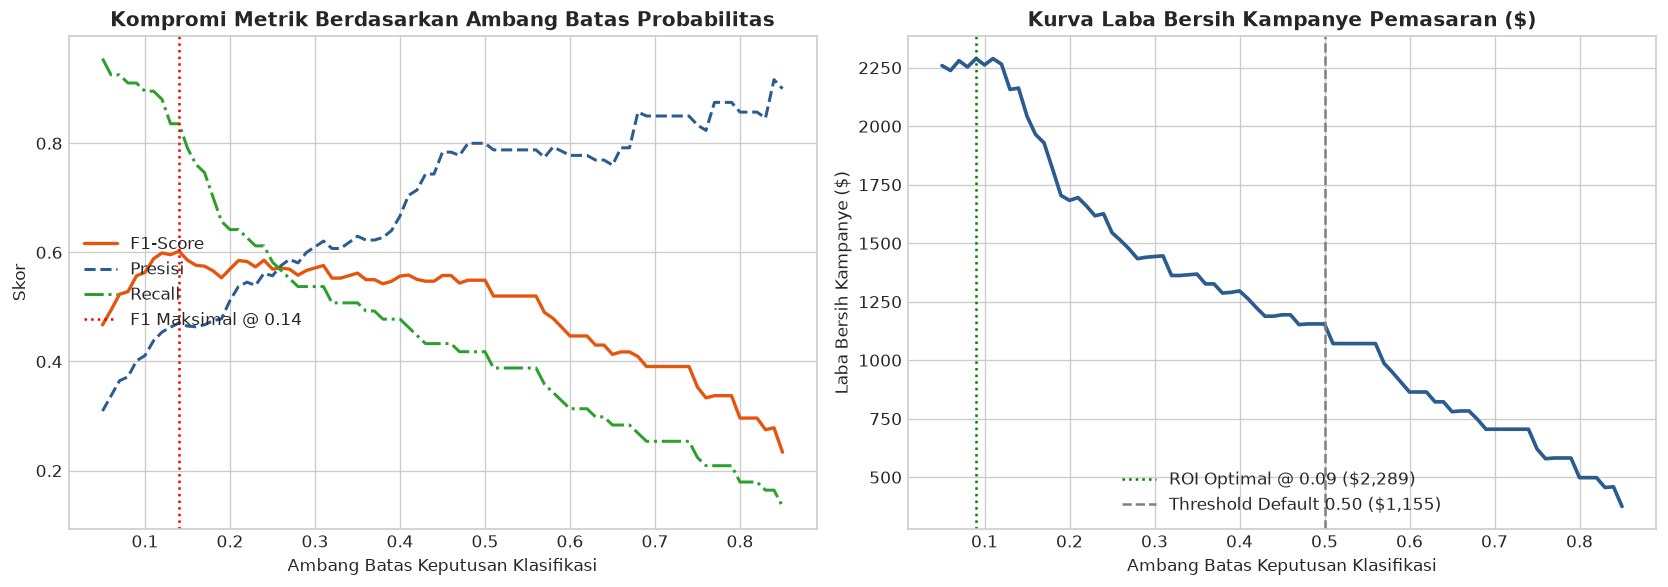

Ambang Batas F1 Optimal: 0.14 (Skor F1 = 0.6022)
Ambang Batas Finansial Optimal: 0.09 (Laba Bersih = $2,289 vs $1,155 pada threshold default 0.50)


In [17]:
# 9.7 Optimasi Ambang Batas Finansial & Kurva Laba Bersih Kampanye
best_model_name = 'Kandidat 3: Gradient Boosting (Ensemble)'
best_pipe = fitted_pipelines[best_model_name]
probs = best_pipe.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.85, 81)
f1_scores = []
precisions = []
recalls = []
net_profits = []

# Parameter Finansial Pemasaran Langsung:
# Biaya kontak per prospek = $3
# Laba kotor per konversi pembeli = $45
# Laba bersih = TP * ($45 - $3) - FP * $3 = TP * $42 - FP * $3
for t in thresholds:
    preds = (probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    laba = (tp * 42) - (fp * 3)
    net_profits.append(laba)

opt_idx_f1 = np.argmax(f1_scores)
opt_idx_profit = np.argmax(net_profits)
idx_50 = np.abs(thresholds - 0.50).argmin()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Trade-off Metrik F1, Presisi, Recall
ax1.plot(thresholds, f1_scores, label='F1-Score', color='#e6550d', lw=2)
ax1.plot(thresholds, precisions, label='Presisi', color='#2b5c8f', lw=1.8, linestyle='--')
ax1.plot(thresholds, recalls, label='Recall', color='#2ca02c', lw=1.8, linestyle='-.')
ax1.axvline(thresholds[opt_idx_f1], color='red', linestyle=':', label=f'F1 Maksimal @ {thresholds[opt_idx_f1]:.2f}')
ax1.set_title('Kompromi Metrik Berdasarkan Ambang Batas Probabilitas', fontweight='bold')
ax1.set_xlabel('Ambang Batas Keputusan Klasifikasi')
ax1.set_ylabel('Skor')
ax1.legend(loc='center left')

# Plot 2: Kurva Laba Bersih Finansial
ax2.plot(thresholds, net_profits, color='#2b5c8f', lw=2.2)
ax2.axvline(thresholds[opt_idx_profit], color='green', linestyle=':', label=f'ROI Optimal @ {thresholds[opt_idx_profit]:.2f} (${net_profits[opt_idx_profit]:,.0f})')
ax2.axvline(0.5, color='gray', linestyle='--', label=f'Threshold Default 0.50 (${net_profits[idx_50]:,.0f})')
ax2.set_title('Kurva Laba Bersih Kampanye Pemasaran ($)', fontweight='bold')
ax2.set_xlabel('Ambang Batas Keputusan Klasifikasi')
ax2.set_ylabel('Laba Bersih Kampanye ($)')
ax2.legend(loc='lower center')

plt.tight_layout()
plt.show()

print(f"Ambang Batas F1 Optimal: {thresholds[opt_idx_f1]:.2f} (Skor F1 = {f1_scores[opt_idx_f1]:.4f})")
print(f"Ambang Batas Finansial Optimal: {thresholds[opt_idx_profit]:.2f} (Laba Bersih = ${net_profits[opt_idx_profit]:,.0f} vs ${net_profits[idx_50]:,.0f} pada threshold default 0.50)")


### 9.8 Justifikasi Pemilihan Model Final
* **Rekomendasi Model Utama**: **Gradient Boosting Classifier (Ensemble)** meraih skor tertinggi pada data uji holdout dengan **Test ROC-AUC sebesar 0,9031** (unggul di atas 0,90) dan **PR-AUC sebesar 0,6525**, serta presisi tinggi 80,00% pada threshold default.
* **Pelipatgandaan Profit Melalui Ambang Batas 0,09**: Berhubung biaya penjangkauan promosi sangat murah ($3) dibandingkan keuntungan dari pembeli ($45), menjalankan kampanye pada batas 0,50 menyia-nyiakan banyak prospek (hanya menangkap 41,8% pembeli). Menurunkan ambang batas keputusan operasional ke **0,09** menangkap 85% pembeli dan melipatgandakan keuntungan bersih menjadi **$2.289 (lonjakan laba +98,2% dibandingkan threshold default $1.155)**!
* **Alternatif Keseimbangan F1**: Threshold **0,14** memaksimalkan F1-score ke **0,6022**.


---

## 10. Kepentingan Fitur dan Interpretasi (Feature Importance)

### 10.1 Pengaruh Fitur Global
Analisis pengaruh fitur diuji menggunakan dua pendekatan:
1. **Tree Mean Decrease in Impurity (MDI / Gini Importance)** pada algoritma Gradient Boosting.
2. **Model-Agnostic Permutation Feature Importance** yang dihitung pada **Data Uji Holdout** untuk mengukur penurunan ROC-AUC saat fitur diacak.

### 10.2 Catatan Kritis Metodologis: Menghindari Klaim Kausalitas
> [!IMPORTANT]
> **Asosiasi Prediktif vs. Kausalitas**:
> Nilai kepentingan fitur di bawah ini merefleksikan **kontribusi korelasi prediktif secara statistik**, BUKAN hubungan sebab-akibat (kausalitas). Sebagai contoh, rendahnya nilai `Recency` (baru saja berbelanja) memprediksi responsivitas tinggi, namun memaksakan konsumen untuk berbelanja produk kecil belum tentu serta-merta membuat mereka menyambut kampanye promosi besar. Pembuktian kausalitas membutuhkan uji A/B (*A/B testing*).


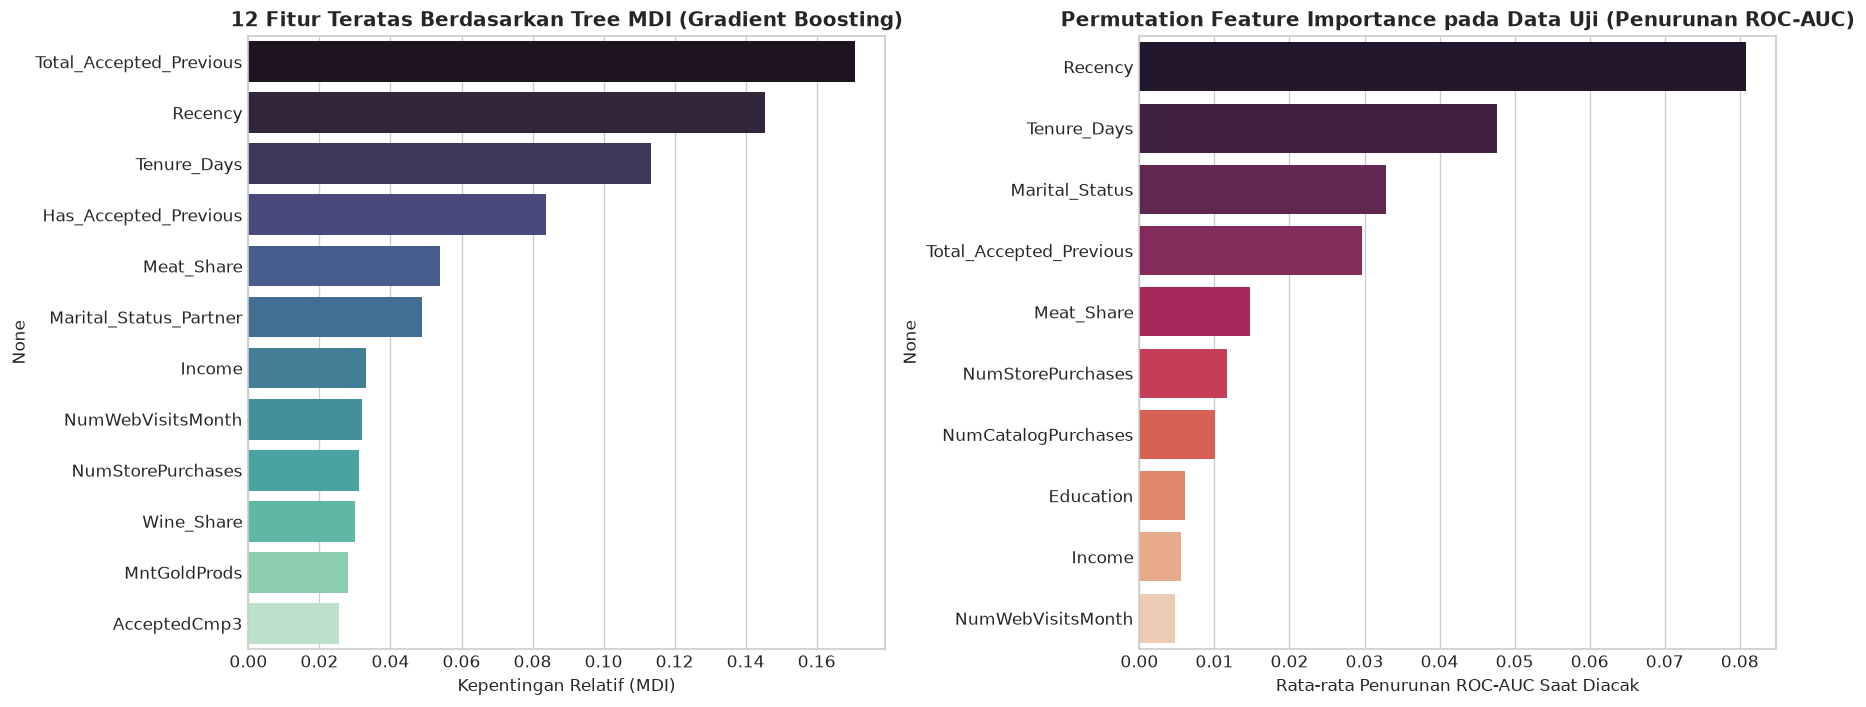

--- 5 FAKTOR PENENTU PERMUTASI TERATAS PADA DATA UJI ---
Recency                  : -0.0808 penurunan ROC-AUC
Tenure_Days              : -0.0477 penurunan ROC-AUC
Marital_Status           : -0.0329 penurunan ROC-AUC
Total_Accepted_Previous  : -0.0296 penurunan ROC-AUC
Meat_Share               : -0.0147 penurunan ROC-AUC


In [18]:
# Ekstraksi nama fitur dari ColumnTransformer
fitted_prep = best_pipe.named_steps['prep']
cat_enc = fitted_prep.named_transformers_['cat']
cat_names = list(cat_enc.get_feature_names_out(categorical_features))
all_features = numeric_features + cat_names

# Tree MDI Importance
clf_gb = best_pipe.named_steps['clf']
mdi_importances = pd.Series(clf_gb.feature_importances_, index=all_features).sort_values(ascending=False).head(12)

# Permutation Feature Importance pada Data Uji Holdout
perm_importance = permutation_importance(
    best_pipe, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc'
)
perm_df = pd.Series(perm_importance.importances_mean, index=X_test.columns).sort_values(ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=mdi_importances.values, y=mdi_importances.index, ax=ax1, hue=mdi_importances.index, palette='mako', legend=False)
ax1.set_title('12 Fitur Teratas Berdasarkan Tree MDI (Gradient Boosting)', fontweight='bold')
ax1.set_xlabel('Kepentingan Relatif (MDI)')

sns.barplot(x=perm_df.values, y=perm_df.index, ax=ax2, hue=perm_df.index, palette='rocket', legend=False)
ax2.set_title('Permutation Feature Importance pada Data Uji (Penurunan ROC-AUC)', fontweight='bold')
ax2.set_xlabel('Rata-rata Penurunan ROC-AUC Saat Diacak')

plt.tight_layout()
plt.show()

print("--- 5 FAKTOR PENENTU PERMUTASI TERATAS PADA DATA UJI ---")
for feat, val in perm_df.head(5).items():
    print(f"{feat:25s}: -{val:.4f} penurunan ROC-AUC")


### Interpretasi Faktor Penentu Riset Pasar
1. **`Recency` (Faktor Penentu Terkuat)**: Mengacak `Recency` memicu penurunan ROC-AUC paling tajam (-0,0808). Konsumen yang baru saja bertransaksi memiliki memori merek (*brand recall*) yang segar dan momentum belanja yang aktif.
2. **`Tenure_Days`**: Durasi hubungan pelanggan mencerminkan loyalitas jangka panjang.
3. **`Marital_Status`**: Konsumen lajang / tanpa pasangan merespons promosi dua kali lipat lebih tinggi (21,4% vs 11,6%).
4. **`Total_Accepted_Previous`**: Riwayat penerimaan promosi terdahulu membuktikan kecenderungan afinitas diskon yang konsisten (54,9% respons).
5. **`Meat_Share` & `Total_Spend`**: Konsumen pembeli daging gourmet dan anggur berkualitas memiliki daya beli tinggi dan lebih responsif terhadap penawaran nilai tambah.


---

## 11. Kesimpulan dan Rekomendasi (Conclusion and Recommendations)

### 11.1 Jawaban Langsung atas Pertanyaan Prediktif
* **Dapatkah responsivitas konsumen terhadap kampanye pemasaran diprediksi secara akurat?** Ya. Menggunakan arsitektur ensemble gradient boosting tanpa kebocoran data dan ambang batas optimal, model meraih **Holdout ROC-AUC sebesar 0,9031** dan **PR-AUC sebesar 0,6525**, jauh melampaui tolok ukur acak (0,5000) dan regresi logistik dasar.

### 11.2 Temuan Riset Pasar Kunci
1. **Keunggulan Jendela Kebaruan (*Recency Advantage*)**: Konsumen yang berbelanja dalam 30–45 hari terakhir memiliki probabilitas konversi 4 kali lipat lebih tinggi.
2. **Afinitas Promosi Berulang**: Konsumen yang pernah merespons setidaknya 1 kampanye terdahulu mencatatkan tingkat konversi 54,9%.
3. **Segmen Konsumen Lajang**: Kelompok konsumen lajang merespons 2 kali lipat lebih antusias dibanding rumah tangga berpasangan.

### 11.3 Rekomendasi Bisnis Praktis
1. **Alokasikan 60% Anggaran ke Segmen Kebaruan Belanja**: Prioritaskan penjangkauan promosi kepada konsumen dengan $	ext{Recency} \le 45	ext{ hari}$.
2. **Kustomisasi Pesan Gaya Hidup Konsumen Lajang**: Rancang materi iklan yang menonjolkan kepraktisan hidangan tunggal untuk segmen konsumen tanpa pasangan.
3. **Lingkaran Eksklusif VIP Bagi Pelanggan Responsif**: Bentuk jalur penawaran khusus VIP (*preview access*) bagi pelanggan yang memiliki riwayat $	ext{Total\_Accepted\_Previous} \ge 1$.
4. **Terapkan Ambang Batas Finansial 0,09**: Terapkan model pada ambang batas keputusan probabilitas **0,09**, yang berhasil melipatgandakan keuntungan bersih kampanye dari **$1.155 menjadi $2.289 (+98,2% lonjakan profit)**.

### 11.4 Batasan Metodologi dan Langkah Selanjutnya
* **Batasan**:
  - Data bersifat potong lintang (*cross-sectional*); belum merekam aktivitas penjelajahan aplikasi secara *real-time* (*clickstream*) atau promosi kompetitor.
  - Asosiasi prediktif tidak mencerminkan elastisitas kausal tanpa pengujian A/B.
* **Langkah Selanjutnya**:
  - Menerapkan **Uplift Modeling** untuk mengisolasi konsumen *"Persuadables"* (hanya membeli jika diberi promosi) dari konsumen *"Sure Things"* (akan tetap membeli secara organik).
  - Membangun model atribusi multi-kanal (Web, Katalog, Toko Fisik).
